Utilizando la función y = 2x^2 - 3x + 1 para generar datos a los que se les aplica ruido para simular imprecisión, se utiliza programación genética para resolver un problema de regresión simbólica y construir una función que relacione las variables de entrada con las variables objetivo

In [ ]:
pip install gplearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 70.1 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


In [ ]:
import pandas as pd
import numpy as np

# Generar datos de entrada 'x'
n_samples = 100
x = np.random.uniform(-5, 5, n_samples)

# Generar la variable objetivo 'y' usando la función real (y = 2x^2 - 3x + 1) y añadir algo de ruido
y = 2 * x**2 - 3 * x + 1 + np.random.normal(0, 0.5, n_samples)

# Crear un DataFrame de pandas
df = pd.DataFrame({'x': x, 'y': y})

display(df.head())


,x,y
0,-1.638536,10.960255
1,2.941781,10.217893
2,1.692547,1.505059
3,4.155154,23.190319
4,-3.050964,28.119732


In [ ]:
from gplearn.genetic import SymbolicRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import graphviz

X = df[['x']].values
y = df['y'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

est_gp = SymbolicRegressor(population_size=5000,
                           generations=20,
                           stopping_criteria=0.01,
                           p_crossover=0.7,
                           p_subtree_mutation=0.1,
                           p_hoist_mutation=0.05,
                           p_point_mutation=0.1,
                           max_samples=0.9,
                           verbose=1,
                           function_set=('add', 'sub', 'mul', 'div'),
                           parsimony_coefficient=0.01,
                           random_state=42,
                           n_jobs=-1)

est_gp.fit(X_train, y_train)

print(f"\nMejor expresión encontrada por GP:\n{est_gp._program}")


    |   Population Average    |             Best Individual              |
---- ------------------------- ------------------------------------------ ----------
 Gen   Length          Fitness   Length          Fitness      OOB Fitness  Time Left
   0    48.21          39964.8      127          1.65484          1.90844      6.78m
   1    30.05          36.0404      127         0.414451          0.42726      1.95m
   2    43.91          1289.85      125         0.398225         0.616749      2.24m
   3    70.63          786.233       31         0.340648         0.581221      2.27m
   4    57.34          34.4563       31         0.338191          0.60334      2.18m
   5    32.00          32.8293       17         0.332507         0.531204      1.40m
   6    19.58          19.0622       15         0.325546         0.619265      1.60m
   7    15.45          21.0006       15         0.318734         0.701087      1.03m
   8    13.91          19.6742       19         0.322118         0.668221  

R^2 en el conjunto de prueba: 0.9989


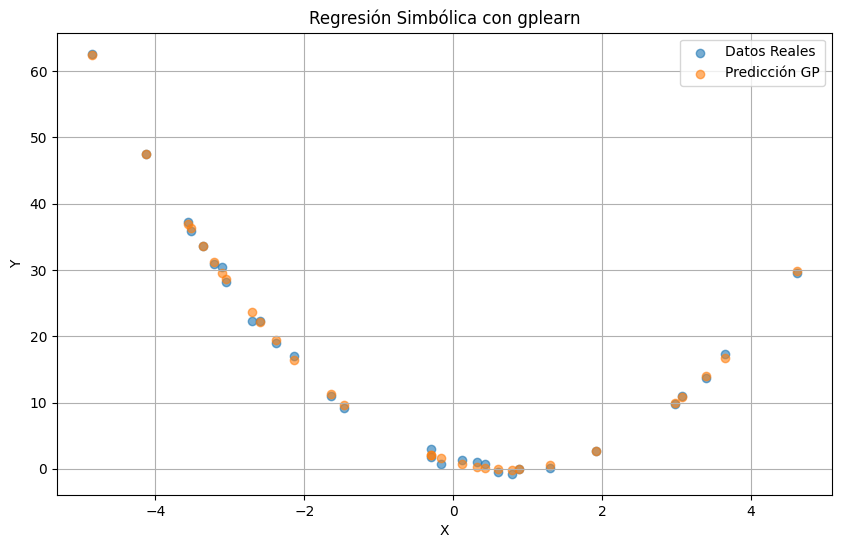

In [ ]:
y_pred = est_gp.predict(X_test)

r2 = r2_score(y_test, y_pred)
print(f"R^2 en el conjunto de prueba: {r2:.4f}")


fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(X_test, y_test, label='Datos Reales', alpha=0.6)
ax.scatter(X_test, y_pred, label='Predicción GP', alpha=0.6)
ax.set_title('Regresión Simbólica con gplearn')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.legend()
ax.grid(True)
plt.show()
